In [1]:
import os
import glob
import numpy as np
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import sys
import matplotlib.pyplot as plt

In [26]:
import Envelope_Analysis as ea

Void = ea.load_waveform('Isolated_Waveforms/8kV_Void000_Ch1_Isolated_001.csv')
Void2 = ea.load_waveform('Isolated_Waveforms/8kV_Void001_Ch1_Isolated_001.csv')
Incision = ea.load_waveform('Isolated_Waveforms/17kV_Incision000_Ch1_Isolated_001.csv')


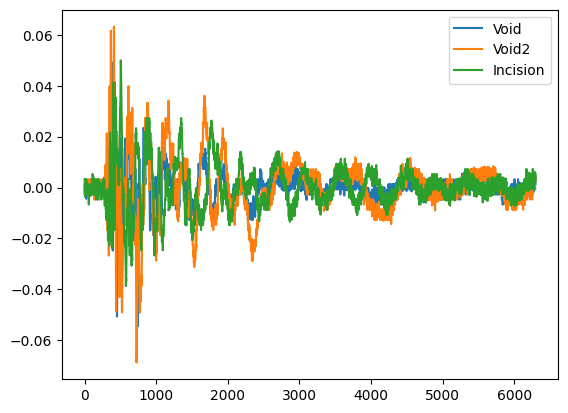

In [27]:
plt.plot(Void, label = 'Void')
plt.plot(Void2, label = 'Void2')
plt.plot(Incision, label = 'Incision')
plt.legend()
plt.show()

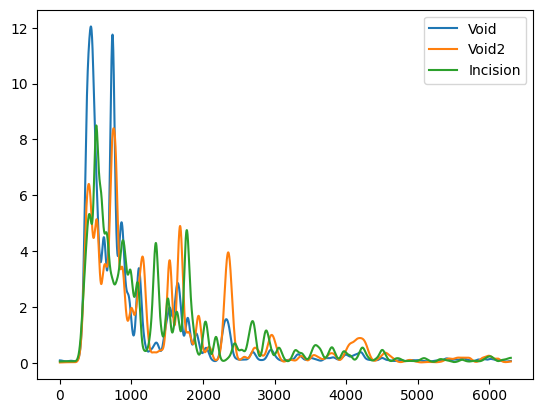

In [28]:

Void_Processed = ea.process_envelope(Void,30)
Void2_Processed = ea.process_envelope(Void2,30)
Incision_Processed = ea.process_envelope(Incision,30)

plt.plot(Void_Processed, label = 'Void')
plt.plot(Void2_Processed, label = 'Void2')
plt.plot(Incision_Processed, label = 'Incision')
plt.legend()
plt.show()

Lag: -97


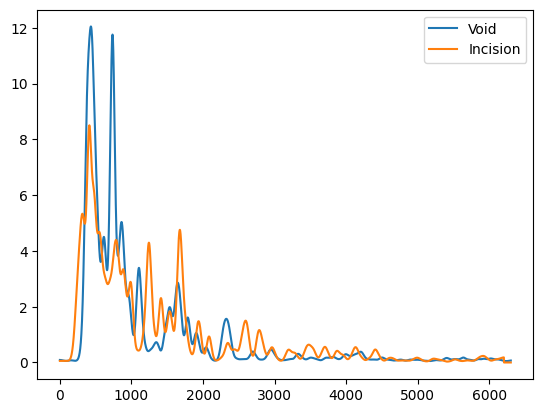

0.5926748708639078


In [29]:
Void_Aligned, Incision_Aligned, idx = ea.align_signals(Void_Processed, Incision_Processed)
plt.plot(Void_Aligned, label = 'Void')
plt.plot(Incision_Aligned, label = 'Incision')
plt.legend()
plt.show()

D = ea.calculate_similarity_D(Void_Aligned, Incision_Aligned, idx)
print(D)

Lag: -12


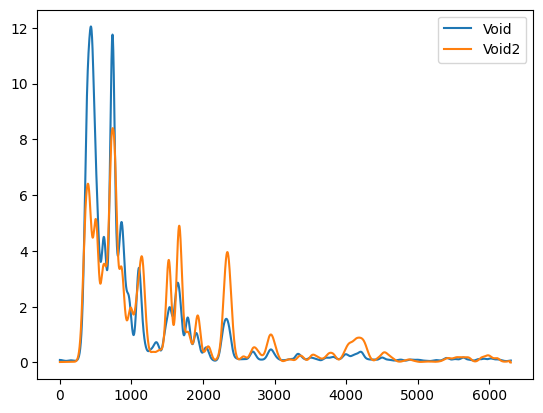

0.4223332927432531


In [30]:
Void_Aligned, Void2_Aligned, idx = ea.align_signals(Void_Processed, Void2_Processed)
plt.plot(Void_Aligned, label = 'Void')
plt.plot(Void2_Aligned, label = 'Void2')
plt.legend()
plt.show()

D = ea.calculate_similarity_D(Void_Aligned, Void2_Aligned, idx)
print(D)


Lag: -126
Lag: 13
Lag: -126
Lag: 13
Lag: -126
Lag: 13
Lag: -126
Lag: 13
Lag: -126
Lag: 12
Lag: -126
Lag: 12
Lag: -126
Lag: 12
Lag: -126
Lag: 11
Lag: -127
Lag: 11
Lag: -127
Lag: 10
Lag: -127
Lag: 10
Lag: -127
Lag: 8
Lag: -127
Lag: 7
Lag: -127
Lag: 5
Lag: -127
Lag: 2
Lag: -126
Lag: -2
Lag: -126
Lag: -6
Lag: -125
Lag: -8
Lag: -124
Lag: -10
Lag: -123
Lag: -11
Lag: -121
Lag: -12
Lag: -119
Lag: -12
Lag: -117
Lag: -12
Lag: -115
Lag: -13
Lag: -112
Lag: -13
Lag: -109
Lag: -13
Lag: -106
Lag: -13
Lag: -103
Lag: -12
Lag: -100
Lag: -12
Lag: -97
Lag: -12
Lag: -95
Lag: -12
Lag: -93
Lag: -12
Lag: -90
Lag: -12
Lag: -88
Lag: -11
Lag: -86
Lag: -11
Lag: -85
Lag: -11
Lag: -83
Lag: -11
Lag: -81
Lag: -11
Lag: -80
Lag: -11
Lag: -79
Lag: -11
Lag: -78
Lag: -10
Lag: -76
Lag: -10
Lag: -75
Lag: -10
Lag: -75
Lag: -10
Lag: -74
Lag: -10
Lag: -73
Lag: -10
Lag: -72
Lag: -10
Lag: -71
Lag: -10
Lag: -71
Lag: -10
Lag: -70
Lag: -10
Lag: -69
Lag: -11
Lag: -69
Lag: -11
Lag: -68
Lag: -11
Lag: -68
Lag: -11
Lag: -67
Lag: -11
Lag

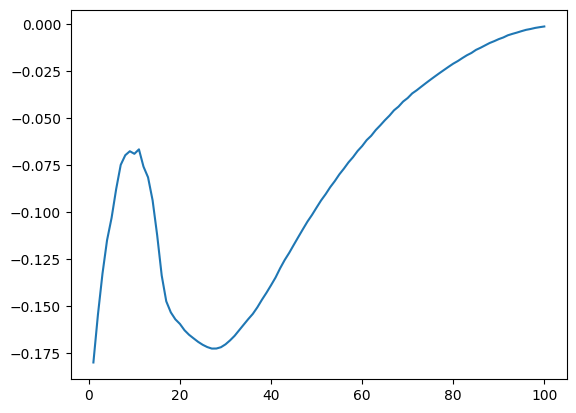

In [31]:
def func(sigma):
    Void_Processed = ea.process_envelope(Void,sigma)
    Void2_Processed = ea.process_envelope(Void2,sigma)
    Incision_Processed = ea.process_envelope(Incision,sigma)

    Void_Aligned, Incision_Aligned, idx = ea.align_signals(Void_Processed, Incision_Processed)
    D1 = ea.calculate_similarity_D(Void_Aligned, Incision_Aligned, idx)

    Void_Aligned, Void2_Aligned, idx = ea.align_signals(Void_Processed, Void2_Processed)
    D2 = ea.calculate_similarity_D(Void_Aligned, Void2_Aligned, idx)

    D = D2-D1
    return D

x = np.linspace(1,100,100)
y = np.array([func(i) for i in x])
plt.plot(x,y)
plt.show()

In [33]:
print(x)
print(y)

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]
[-0.17997077 -0.15448674 -0.13269908 -0.11499726 -0.10306207 -0.08784615
 -0.07497472 -0.0698476  -0.06773469 -0.06910033 -0.06673571 -0.07590888
 -0.08160157 -0.09381887 -0.11229383 -0.13377111 -0.14747815 -0.15335497
 -0.15705482 -0.15948583 -0.1628283  -0.16525056 -0.16715504 -0.16902117
 -0.17057192 -0.17177854 -0.17258385 -0.17255708 -0.17186927 -0.17034158
 -0.16824095 -0.16581636 -0.16284138 -0.15987198 -0.15692128 -0.15416356
 -0.15065936 -0.14664936 -0.14292529 -0.13893733 -0.1

Found 8 signals in Cluster 0. Plotting...


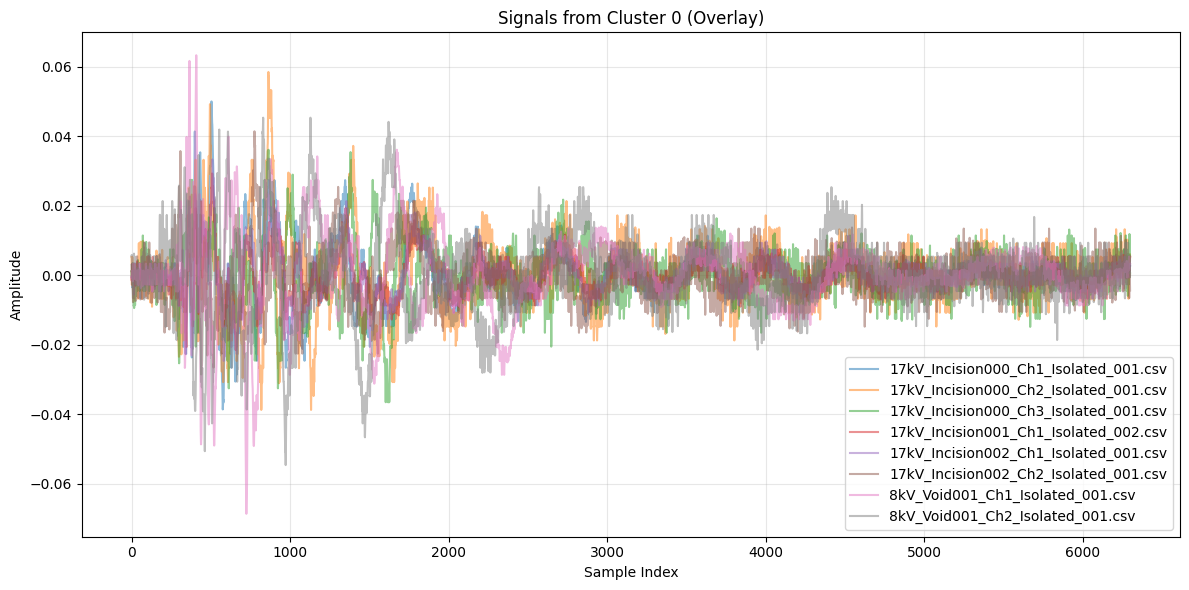

Found 10 signals in Cluster 1. Plotting...


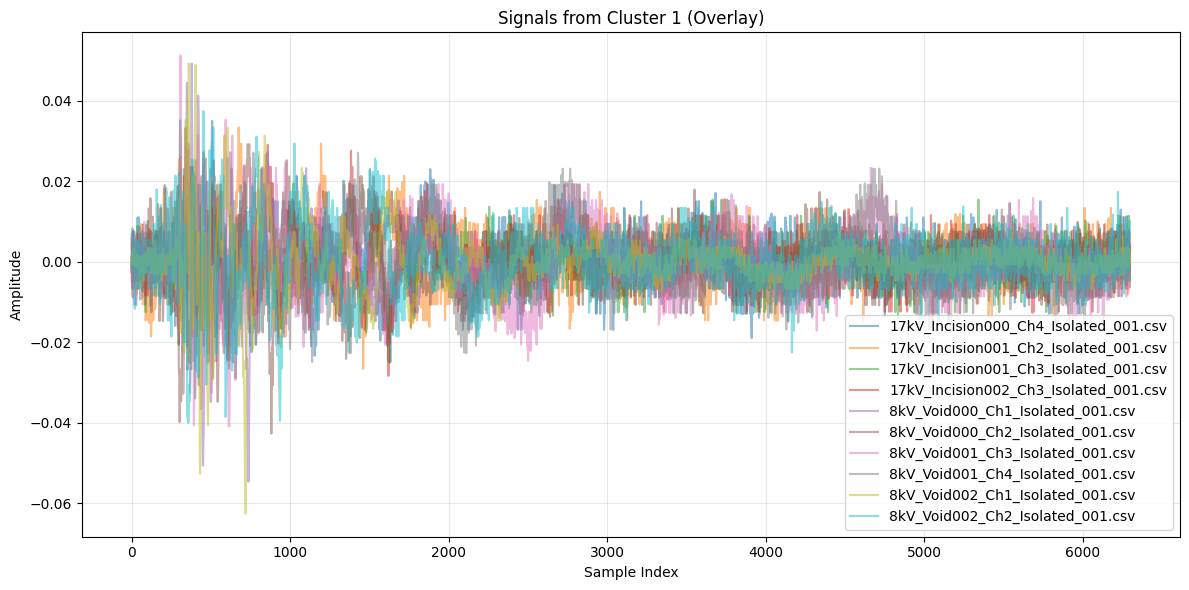

In [5]:
# Plot all signals from one cluster of DBSCAN

import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_signals_from_cluster(features_csv='Wavelet_Features.csv', waveforms_dir='Isolated_Waveforms', target_cluster=0):
    # 1. Load the features with cluster IDs
    if not os.path.exists(features_csv):
        print(f"Error: {features_csv} not found.")
        return

    df = pd.read_csv(features_csv)
    
    if 'Cluster_ID' not in df.columns:
        print("Error: 'Cluster_ID' column missing. Please run DBSCAN.py first.")
        return

    # 2. Filter for the target cluster
    cluster_df = df[df['Cluster_ID'] == target_cluster]
    filenames = cluster_df['Filename'].tolist()
    
    if not filenames:
        print(f"No signals found for Cluster {target_cluster}.")
        return

    print(f"Found {len(filenames)} signals in Cluster {target_cluster}. Plotting...")

    # 3. Plot signals
    plt.figure(figsize=(12, 6))
    
    # Limit number of signals to plot if there are too many
    max_plots = 20
    plot_count = 0
    
    for filename in filenames:
        filepath = os.path.join(waveforms_dir, filename)
        if os.path.exists(filepath):
            try:
                # Load the signal (assuming CSV with Time, Amplitude or just Amplitude)
                sig_df = pd.read_csv(filepath)
                # If there's an 'Amplitude' column, use it; otherwise assume first/last col
                y = sig_df.iloc[:, -1].values # Usually the last column is the signal
                
                plt.plot(y, alpha=0.5, label=filename if len(filenames) <= 10 else "")
                plot_count += 1
            except Exception as e:
                print(f"Could not read {filename}: {e}")
        
        if plot_count >= max_plots:
            print(f"Reached limit of {max_plots} signals for plotting.")
            break

    plt.title(f"Signals from Cluster {target_cluster} (Overlay)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    if len(filenames) <= 10:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_signals_from_cluster(target_cluster=0)
plot_signals_from_cluster(target_cluster=1)

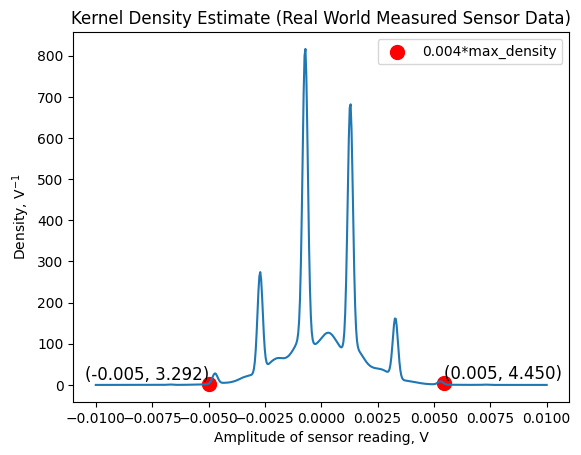

In [15]:
import scipy.stats as stats
x = np.linspace(-0.01, 0.01, 500)
# Calculate the Kernel Density Estimate (KDE) of the amplitude distribution
sig = pd.read_csv("Chiang_Void/8kV_Void000_Ch1.csv", header=None)
sig = sig[1].to_numpy()
sig = sig-sig.mean()
kde = stats.gaussian_kde(sig)
y = kde(x)
idx = np.where(y>=(np.max(y)*0.004))
idx = [idx[0][0], idx[0][-1]]

idx_max = np.where(y==(np.max(y)))
fig, ax = plt.subplots()
ax.plot(x, y)
ax.scatter(x[idx], y[idx], color='red', label='0.004*max_density', s=100)
ax.text(x[idx[0]]-0.0055, y[idx[0]], f'({x[idx[0]]:.3f}, {y[idx[0]]:.3f})', fontsize=12, verticalalignment='bottom')
ax.text(x[idx[-1]], y[idx[-1]], f'({x[idx[-1]]:.3f}, {y[idx[-1]]:.3f})', fontsize=12, verticalalignment='bottom')
ax.set_title("Kernel Density Estimate (Real World Measured Sensor Data)")
ax.set_xlabel("Amplitude of sensor reading, V")
ax.set_ylabel(r"Density, V$^{-1}$")
ax.legend()
plt.show()